# **Spam Mail Prediction**

# **Example**
![Screenshot 2026-09-07 062506.png](<attachment:Screenshot 2026-09-07 062506.png>)
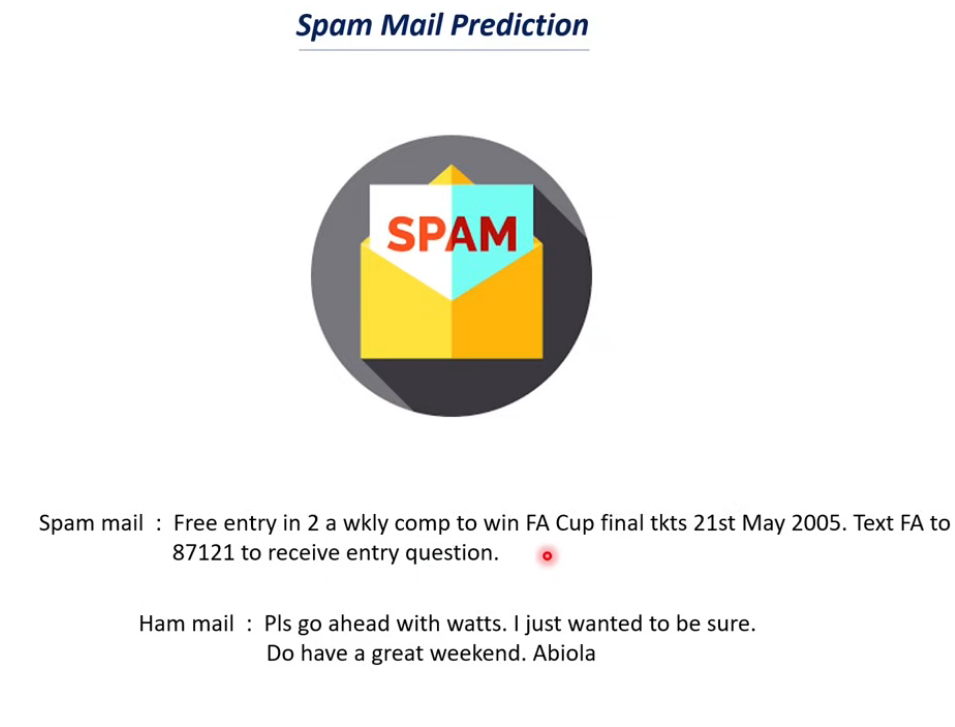

# **WorkFlow**
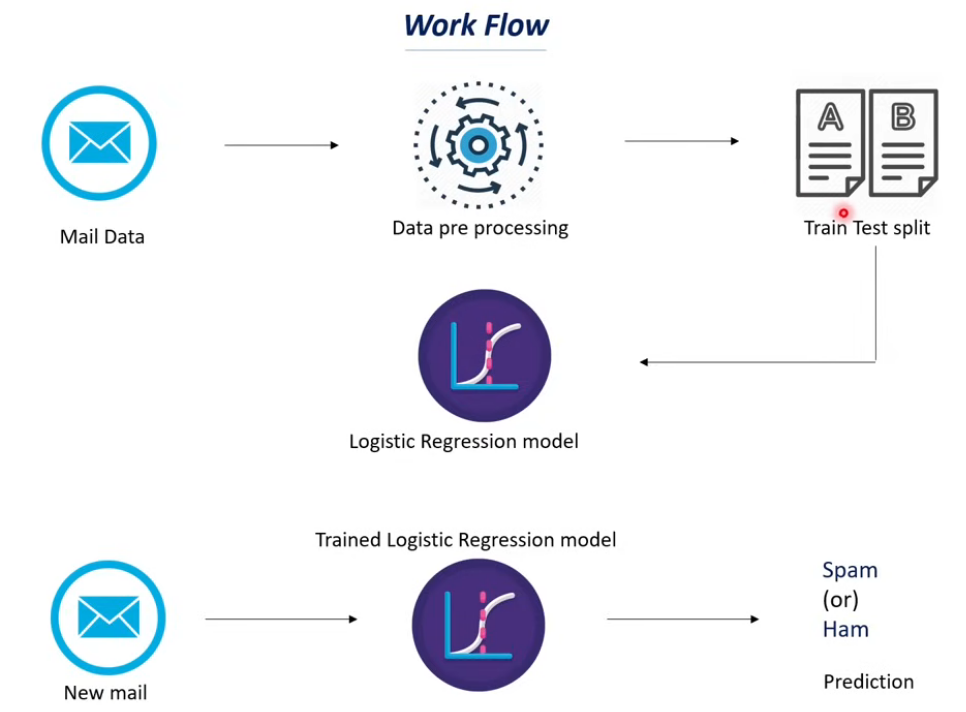

Importing the Dependencies

In [11]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

Data collection and preprocessing

In [5]:
spam_dataset = pd.read_csv('dataset/mail_data.csv')

In [6]:
print(spam_dataset)

     Category                                            Message
0         ham  Go until jurong point, crazy.. Available only ...
1         ham                      Ok lar... Joking wif u oni...
2        spam  Free entry in 2 a wkly comp to win FA Cup fina...
3         ham  U dun say so early hor... U c already then say...
4         ham  Nah I don't think he goes to usf, he lives aro...
...       ...                                                ...
5567     spam  This is the 2nd time we have tried 2 contact u...
5568      ham               Will ü b going to esplanade fr home?
5569      ham  Pity, * was in mood for that. So...any other s...
5570      ham  The guy did some bitching but I acted like i'd...
5571      ham                         Rofl. Its true to its name

[5572 rows x 2 columns]


In [7]:
# replace the null values with a null string
spam_dataset = spam_dataset.where((pd.notnull(spam_dataset)), '')

In [8]:
# printing the first 5 rows of the dataset
spam_dataset.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
# printing the last 5 rows of the dataset
spam_dataset.tail()

,Category,Message
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


In [10]:
# checking the no of the rows and columns in the dataset
spam_dataset.shape

(5572, 2)

# label encoding

In [ ]:
# spam as 1 and not spam as 0
le = LabelEncoder()
spam_dataset['Category'] = le.fit_transform(spam_dataset['Category'])

In [13]:
# printing the first 5 rows of the dataset after label encoding
spam_dataset.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [14]:
# splitting the dataset into X and y
X = spam_dataset['Message']
Y = spam_dataset['Category']

In [15]:
print(X)

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                 Will ü b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: Message, Length: 5572, dtype: str


In [16]:
print(Y)

0       0
1       0
2       1
3       0
4       0
       ..
5567    1
5568    0
5569    0
5570    0
5571    0
Name: Category, Length: 5572, dtype: int64


<Axes: title={'center': 'Count (Category)'}, xlabel='Category'>

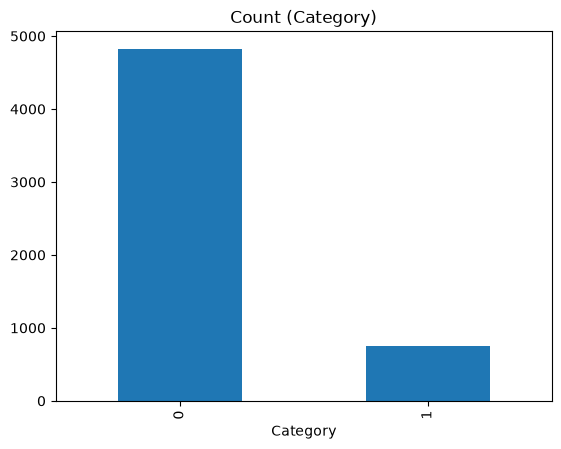

In [17]:
# Histogram with a KDE (Kernel Density Estimate) Line
spam_dataset['Category'].value_counts().plot(kind='bar', title='Count (Category)')

<Axes: xlabel='Category', ylabel='Count'>

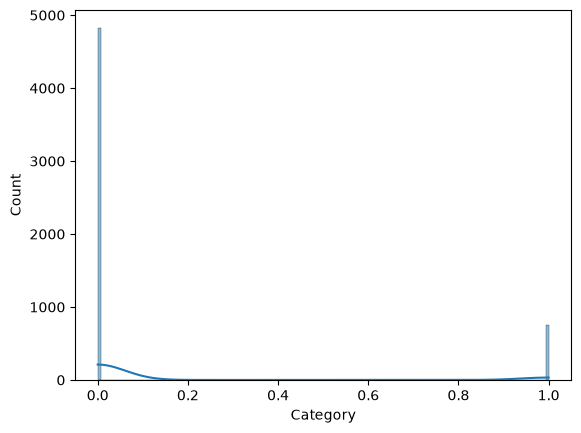

In [18]:
sns.histplot(spam_dataset['Category'], kde=True)

# Split the train and test data

In [27]:
# train test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, stratify = Y, random_state = 3)

In [28]:
# X shapes
print(X.shape, X_train.shape, X_test.shape)

(5572,) (4457,) (1115,)


In [29]:
# Y shapes
print(Y.shape, Y_train.shape, Y_test.shape)

(5572,) (4457,) (1115,)


In [30]:
print(X_train)

2020               From tomorrow onwards eve 6 to 3 work.
3453                             Ugh just got outta class
3364                                   Can... I'm free...
2597    No i'm not gonna be able to. || too late notic...
5491    U studying in sch or going home? Anyway i'll b...
                              ...                        
3775                                Ok... But bag again..
5519    Can you pls send me that company name. In saib...
2832                           Thanx 4 sending me home...
2724    Tunde, how are you doing. This is just wishing...
4714    Big brother‘s really scraped the barrel with t...
Name: Message, Length: 4457, dtype: str


In [31]:
print(X_test)

2297    <Forwarded from 21870000>Hi - this is your Mai...
1613    RT-KIng Pro Video Club>> Need help? info@ringt...
4531    Don't forget though that I love you .... And I...
920                 Dont talk to him ever ok its my word.
2328    URGENT! Your mobile number *************** WON...
                              ...                        
1194    Sex up ur mobile with a FREE sexy pic of Jorda...
4664                       No. Yes please. Been swimming?
1200    NEFT Transaction with reference number  &lt;#&...
3211    She said,'' do u mind if I go into the bedroom...
2798    If I get there before you after your ten billi...
Name: Message, Length: 1115, dtype: str


In [32]:
print(Y_train)

2020    0
3453    0
3364    0
2597    0
5491    0
       ..
3775    0
5519    0
2832    0
2724    0
4714    0
Name: Category, Length: 4457, dtype: int64


In [33]:
print(Y_test)

2297    1
1613    1
4531    0
920     0
2328    1
       ..
1194    1
4664    0
1200    0
3211    0
2798    0
Name: Category, Length: 1115, dtype: int64


In [34]:
# transforming the text data to feature vectors that can be used as input to the logistic regression model
feature_extraction = TfidfVectorizer(min_df=1, stop_words='english', lowercase= True)
X_train_features = feature_extraction.fit_transform(X_train)
X_test_features = feature_extraction.transform(X_test)

# convert Y_train and Y_test values as integers
Y_train = Y_train.astype('int')
Y_test = Y_test.astype('int')

In [35]:
print(X_train_features)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 34822 stored elements and shape (4457, 7485)>
  Coords	Values
  (0, 6736)	0.40433070936297943
  (0, 4795)	0.6459507464707183
  (0, 2596)	0.5157331716075019
  (0, 7329)	0.39151450331197035
  (1, 6887)	0.528038275197618
  (1, 3758)	0.2826422333927384
  (1, 3112)	0.31103507183699425
  (1, 4861)	0.596185515774092
  (1, 1793)	0.43486660333673016
  (2, 2903)	1.0
  (3, 3092)	0.32479862316475455
  (3, 758)	0.37620667903348365
  (3, 3909)	0.3260348921371232
  (3, 4692)	0.43001182720880177
  (3, 4040)	0.24099748417300504
  (3, 3373)	0.26859638268284747
  (3, 7198)	0.3971508483254661
  (3, 5081)	0.4169087023760639
  (4, 4040)	0.21533285461106827
  (4, 3373)	0.2399926539473106
  (4, 6339)	0.3725106977896412
  (4, 5766)	0.6833422922401591
  (4, 3082)	0.4766800108257891
  (4, 3911)	0.2511783165875194
  (5, 5274)	0.5140146308140942
  :	:
  (4452, 4770)	0.4790816639408472
  (4452, 1180)	0.8777703340143531
  (4453, 5831)	0.2807786224274476
 

# Train the Model

In [36]:
# Logistic Regression model
model = LogisticRegression()

# train the model with the training data
model.fit(X_train_features, Y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [37]:
# accuracy on the training data
X_train_prediction = model.predict(X_train_features)
training_data_accuracy = accuracy_score(Y_train, X_train_prediction)
print('Accuracy on training data: ', training_data_accuracy)

Accuracy on training data:  0.9679156383217411


In [38]:
# accuracy on the testing data
X_test_prediction = model.predict(X_test_features)
test_data_accuracy = accuracy_score(Y_test, X_test_prediction)
print('Accuracy on testing data: ', test_data_accuracy)

Accuracy on testing data:  0.9632286995515695


# Prediction model

In [39]:
# Prediction system
input_data = input('Enter the message: ')

# change text to feature vectors
input_data_features = feature_extraction.transform([input_data])

# make prediction
prediction = model.predict(input_data_features)

if prediction[0] == 1:
    print('Spam mail')
else:
    print('Not Spam mail')

Not Spam mail
